# **SaaS Customer Churn Prediction and Early Warning Retention System**

**Pipeline Execution and Model Training**

> **Overview:** This file serves as the main execution script. It imports modularized classes and functions from `utils.py`, loads the dataset, executes the preprocessing and training pipeline, and saves the final trained model artifacts

 --- Step 1: Import all necessary classes from utils.py ---

In [ ]:
import sys
sys.path.append(r"D:\Enterprise Customer Intelligence and Support Ecosystem\SaaS_Churn_Project")
from src.utilis import (
    DataCleaner,
    ChurnEngineer,
    CustomerEDA,
    ChurnFeatureEngineer,
    ChurnDataSplitter,
    ChurnModelTrainer, 
    ChurnModelEvaluator, 
    save_pipeline
)

 --- Step 2: **Phase 1 - Data Cleaning** ---

In [ ]:
data_cleaning = DataCleaner(r"D:\\SaaS_Churn_Project\data\messy_customer_data.csv")
df_cleaned = data_cleaning.run_cleaning_pipeline()

Dataset loaded successfully!
--- Dataset Information ---
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerID          7621 non-null   str    
 1   Name                8342 non-null   str    
 2   Gender              7545 non-null   str    
 3   Age                 7424 non-null   float64
 4   City                8870 non-null   str    
 5   Signup_Date         7471 non-null   str    
 6   Last_purchase_date  6714 non-null   str    
 7   purchase_amount     4967 non-null   float64
 8   feedback_score      7538 non-null   float64
 9   email               4934 non-null   str    
 10  Phone_number        7556 non-null   str    
 11  Country             8296 non-null   str    
dtypes: float64(3), str(9)
memory usage: 1.4 MB
None

--- First 5 Rows of Data ---


,CustomerID,Name,Gender,Age,City,Signup_Date,Last_purchase_date,purchase_amount,feedback_score,email,Phone_number,Country
0,NaN,Ankit,F,36.0,Mumbai,31/12/2024,13/08/2025,-999.0,2.0,NaN,0,Canada
1,C2,Ravi,Female,NaN,Kolkata,NaN,NaN,NaN,-1.0,user1mail.com,abc123,Canada
2,3,Ravi,female,66.0,Ahmedabad,NaN,20/06/2023,NaN,10.0,user2@mail.com,abc123,India
3,C4,Ankit,male,44.0,Kolkata,NaN,13/09/2025,NaN,NaN,NaN,9316267914,USA
4,5,Rahul,Male,200.0,Ahmedabad,09/07/2025,NaN,-999.0,NaN,user4mail.com,9234603292,USA


--- Missing Values Before Cleaning ---
CustomerID            2379
Name                  1658
Gender                2455
Age                   2576
City                  1130
Signup_Date           2529
Last_purchase_date    3286
purchase_amount       5033
feedback_score        2462
email                 5066
Phone_number          2444
Country               1704
dtype: int64
--- Data Cleaning Successful! ---
Total remaining missing values: 0

--- Final Cleaned DataFrame Preview ---


,CustomerID,Name,Gender,Age,City,Signup_Date,Last_purchase_date,purchase_amount,feedback_score,email,Phone_number,Country
0,Unknown,Ankit,Female,36.000000,Mumbai,31/12/2024,13/08/2025,2552.440000,2.000000,Unknown,0,Canada
1,C2,Ravi,Female,36.600000,Kolkata,Unknown,Unknown,3456.286000,-1.000000,user1mail.com,abc123,Canada
2,3,Ravi,Female,66.000000,Ahmedabad,Unknown,20/06/2023,1966.398000,10.000000,user2@mail.com,abc123,India
3,C4,Ankit,Male,44.000000,Kolkata,Unknown,13/09/2025,1179.112000,3.400000,Unknown,9316267914,USA
4,5,Rahul,Male,43.698174,Ahmedabad,09/07/2025,Unknown,2450.615758,4.008092,user4mail.com,9234603292,USA


 --- Step 3: **Phase 2 - EDA (Visualizations)** ---

--- Summary Statistics ---


,Age,purchase_amount,feedback_score
count,10000.000000,10000.000000,10000.000000
mean,41.056518,2458.615284,3.984358
std,8.868932,903.073205,4.066603
min,18.000000,10.310000,-1.000000
25%,36.000000,1816.378000,-0.200000
50%,39.600000,2450.615758,4.000000
75%,44.400000,3144.357500,10.000000
max,70.000000,4998.670000,10.000000



--- Generating Visualizations ---


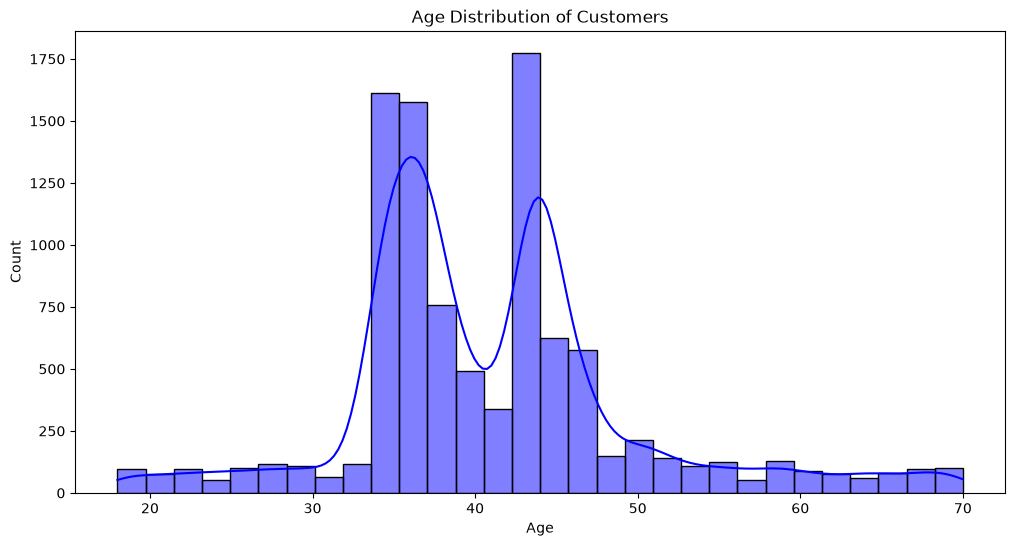

Column 'Churn' not found in dataset.
Columns not found for plotting.


In [24]:
Eda = CustomerEDA(df_cleaned)
Eda.run_eda_pipeline()

 --- Step 4: **Phase 3 Synthetic Target Engineering and Churn Generation** ---

In [25]:
Churn = ChurnEngineer(df_cleaned)
df_with_churn = Churn.get_or_create_churn() 

--- 'Churn' column not found. Generating synthetic Churn using business logic... ---
--- Synthetic Churn Target Generated Successfully ---
Churn
0    0.7884
1    0.2116
Name: proportion, dtype: float64


D:\SaaS_Churn_Project\src\utilis.py:96: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Signup_Date'] = pd.to_datetime(df['Signup_Date'], errors='coerce')
D:\SaaS_Churn_Project\src\utilis.py:97: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Last_purchase_date'] = pd.to_datetime(df['Last_purchase_date'], errors='coerce')


 ---Step 3 : **Phase 2 Exploratory Data Analysis (EDA) After Churn Target Generation**---


--- Summary Statistics ---


,Age,Signup_Date,Last_purchase_date,purchase_amount,feedback_score,Inactivity_Days,Churn
count,10000.000000,4996,3348,10000.000000,10000.000000,3348.000000,10000.000000
mean,41.056518,2023-05-03 09:00:43.234587,2023-05-04 10:07:18.709677,2458.615284,3.984358,996.578256,0.211600
min,18.000000,2020-08-06 00:00:00,2020-08-06 00:00:00,10.310000,-1.000000,0.000000,0.000000
25%,36.000000,2021-12-20 18:00:00,2022-01-07 00:00:00,1816.378000,-0.200000,500.000000,0.000000
50%,39.600000,2023-05-02 12:00:00,2023-04-30 00:00:00,2450.615758,4.000000,1001.000000,0.000000
75%,44.400000,2024-09-13 00:00:00,2024-09-12 00:00:00,3144.357500,10.000000,1479.000000,0.000000
max,70.000000,2026-01-26 00:00:00,2026-01-25 00:00:00,4998.670000,10.000000,1998.000000,1.000000
std,8.868932,NaN,NaN,903.073205,4.066603,576.829425,0.408463



--- Generating Visualizations ---


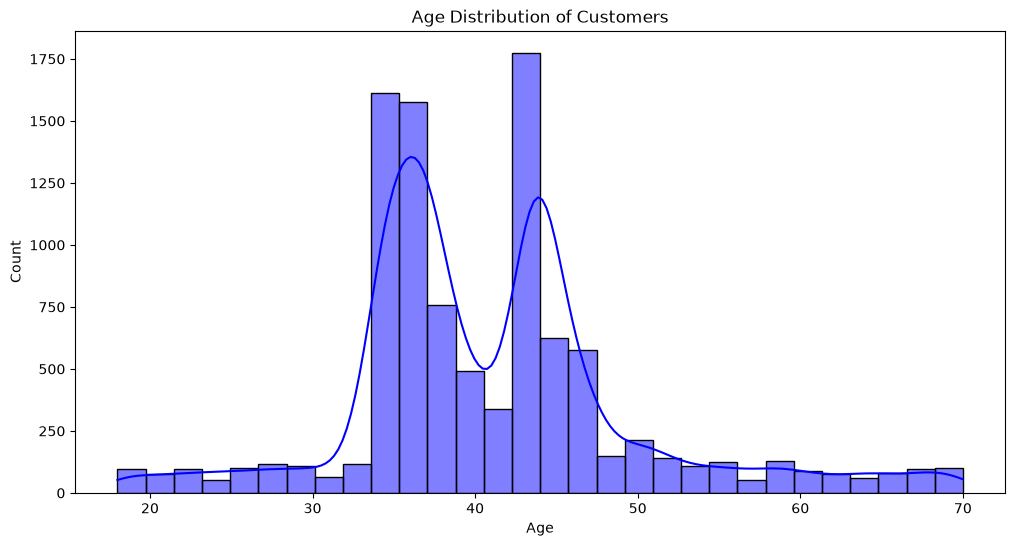

D:\SaaS_Churn_Project\src\utilis.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=self.df, palette='Set2')


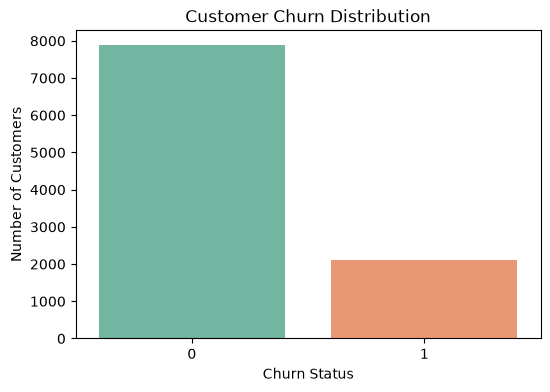

D:\SaaS_Churn_Project\src\utilis.py:152: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=column_name, data=self.df, palette='Set3')


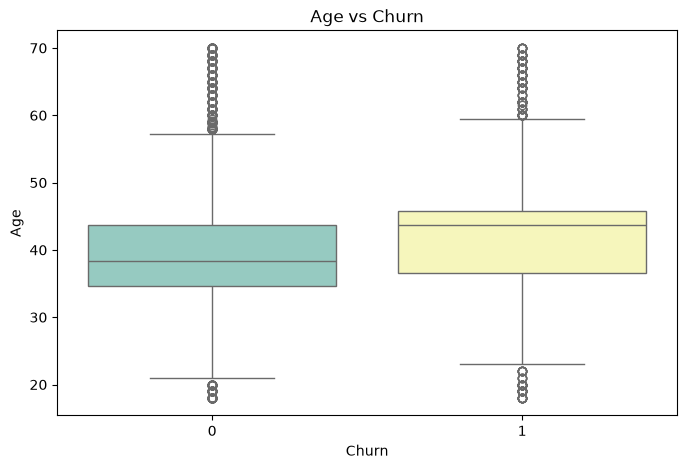

In [26]:
eda = CustomerEDA(df_with_churn)
eda.run_eda_pipeline()

 --- Step 5: **Phase 4 - Feature Engineering & Encoding** ---

In [27]:
fe = ChurnFeatureEngineer(df=df_with_churn, target_column='Churn')
X, y = fe.preprocess_and_encode()


--- Phase 3: Feature Engineering & Encoding ---
Features shape: (10000, 13), Target shape: (10000,)


 --- Step 6: **Phase 5 - Train-Test Split & Scaling** ---

In [28]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = X.select_dtypes(include=['number'])
splitter = ChurnDataSplitter(scaler=scaler)
X_train_scaled, X_test_scaled, y_train, y_test = splitter.split_data(X, y)


--- Phase 4: Train-Test Split ---
Training set rows: 8000
Testing set rows: 2000


 --- Step 7: **Phase 6 - Model Training and Evaluation** ---

In [29]:
trainer = ChurnModelTrainer()
trained_models = trainer.train_models(X_train_scaled, y_train)

print("\nodels successfully trained")


--- Phase 5: Model Training ---
Null values detected in X_train. Applying KNN Imputer before training...
Logistic Regression successfully trained!
Random Forest successfully trained!


c:\Users\Hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SVM successfully trained!
XGBoost successfully trained!

odels successfully trained


 --- Step 7: **Phase 6 - Model Training and Evaluation**---


--- Phase 6: Evaluation and Metrics ---
Null values detected in X_test. Applying KNN Imputer...

Evaluating Logistic Regression:
Accuracy: 0.8665
ROC-AUC Score: 0.8335
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.98      0.92      1577
           1       0.84      0.45      0.59       423

    accuracy                           0.87      2000
   macro avg       0.86      0.72      0.76      2000
weighted avg       0.86      0.87      0.85      2000

Confusion Matrix:
[[1541   36]
 [ 231  192]]


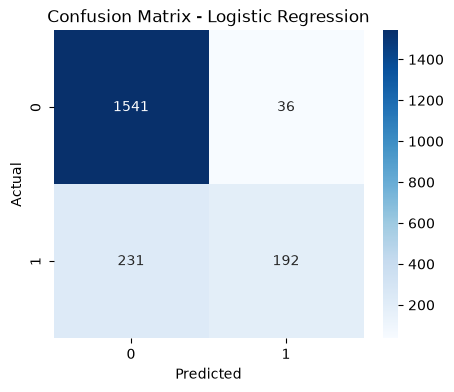


Evaluating Random Forest:
Accuracy: 0.9490
ROC-AUC Score: 0.9120
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97      1577
           1       0.93      0.83      0.87       423

    accuracy                           0.95      2000
   macro avg       0.94      0.90      0.92      2000
weighted avg       0.95      0.95      0.95      2000

Confusion Matrix:
[[1549   28]
 [  74  349]]


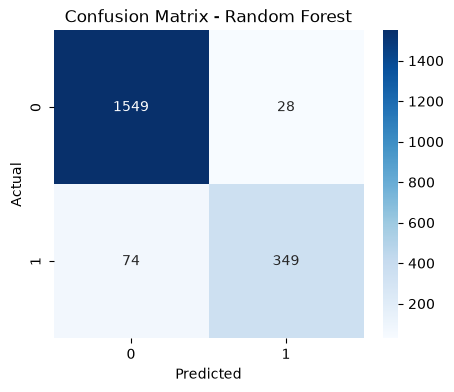


Evaluating SVM:
Accuracy: 0.9200
ROC-AUC Score: 0.9046
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      1577
           1       0.92      0.68      0.78       423

    accuracy                           0.92      2000
   macro avg       0.92      0.83      0.87      2000
weighted avg       0.92      0.92      0.92      2000

Confusion Matrix:
[[1553   24]
 [ 136  287]]


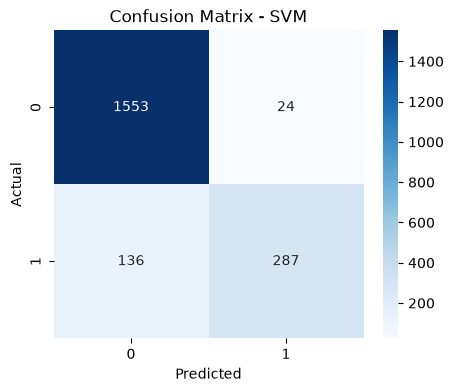


Evaluating XGBoost:
Accuracy: 0.9450
ROC-AUC Score: 0.9084
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97      1577
           1       0.92      0.81      0.86       423

    accuracy                           0.94      2000
   macro avg       0.94      0.90      0.91      2000
weighted avg       0.94      0.94      0.94      2000

Confusion Matrix:
[[1547   30]
 [  80  343]]


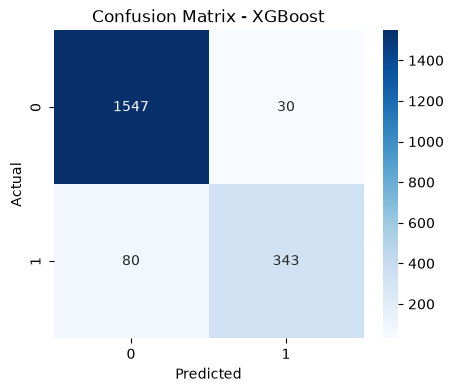


Best Performing Model: Random Forest with Accuracy: 0.9490

Training pipeline complete! Best model selected: RandomForestClassifier(random_state=42)


In [30]:
evaluator = ChurnModelEvaluator()
best_model = evaluator.evaluate_models(models_dict=trained_models, X_test=X_test_scaled, y_test=y_test)
print(f"\nTraining pipeline complete! Best model selected: {best_model}")

 ---Step 8: **Phase 7 - Saving the Model Pipeline**---

In [31]:
save_pipeline(
    best_model=best_model, 
    scaler=splitter.scaler, 
    label_encoders=fe.label_encoders,
)


Pipeline successfully saved as 'churn_model_pipeline.pkl'!
